# Lensless Demo

In [1]:
from pathlib import Path
import subprocess
import os
import sys
import zipfile

### Checking if demo is located in repo root. In other case cloning the repo

In [2]:
REPO_URL = "https://github.com/m-dumbduck/lensless.git"
REPO_FOLDER = "lensless"
EXPECTED_FILE = ".is_repo"
EXPECTED_TEXT_IN_FILE = "lensless"

def check_indicator(path):
    indicator = Path.cwd() / path / EXPECTED_FILE
    if not indicator.is_file():
        return False
    return indicator.read_text(encoding="utf-8").strip() == EXPECTED_TEXT_IN_FILE

In [3]:
if not check_indicator('.') and not check_indicator(REPO_FOLDER):
    subprocess.run(["git", "clone", REPO_URL, REPO_FOLDER], check=True)
if check_indicator(REPO_FOLDER):
    os.chdir(REPO_FOLDER)

#### Installing dependencies

In [4]:
!pip install -r requirements.txt

  Cloning https://github.com/ebezzam/waveprop.git to /private/var/folders/rt/hfz4693d7fgbm0g9bydmg48r0000gn/T/pip-install-xchxmxd4/waveprop_6a8dec441415418c801cec4aada10d35
  Running command git clone --filter=blob:none --quiet https://github.com/ebezzam/waveprop.git /private/var/folders/rt/hfz4693d7fgbm0g9bydmg48r0000gn/T/pip-install-xchxmxd4/waveprop_6a8dec441415418c801cec4aada10d35


In [9]:
!pip install "gdown==5.2.0" matplotlib

  Attempting uninstall: gdown
    Found existing installation: gdown 6.1.0
    Uninstalling gdown-6.1.0:
      Successfully uninstalled gdown-6.1.0

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [10]:
import matplotlib.pyplot as plt
from PIL import Image

## Demonstration

You can paste any link to `YOUR_ARCHIVE_LINK`. The link must contain archive of CustomDir structure. The default link is provided.

**CustomDir structure**

```bash
NameOfTheDirectoryWithData
├── lensless
│   ├── ImageID1.png
│   ├── ImageID2.png
│   .
│   .
│   .
│   └── ImageIDn.png
├── masks
│   ├── ImageID1.npy
│   ├── ImageID2.npy
│   .
│   .
│   .
│   └── ImageIDn.npy
└── lensed # ground truth original image, may not exist
    ├── ImageID1.png
    ├── ImageID2.png
    .
    .
    .
    └── ImageIDn.png
```

In [11]:
YOUR_ARCHIVE_LINK = "https://drive.google.com/file/d/1LZaJJkYHRzMx00-zQgTB3PplB41Uq8LV/view?usp=sharing"

### Download and unpack archive

In [12]:
# --------------------------------------------
# You can provide your own custom DATA_DIR and ARCHIVE_PATH

DATA_DIR = Path("data/demo_input")
ARCHIVE_PATH = Path("data/demo_input.zip")

# -------------------------------------------

ARCHIVE_PATH.parent.mkdir(parents=True, exist_ok=True)
subprocess.run(["gdown", "--fuzzy", YOUR_ARCHIVE_LINK, "-O", ARCHIVE_PATH], check=True)

DATA_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ARCHIVE_PATH) as zf:
    zf.extractall(DATA_DIR)

if not (DATA_DIR / "lensless").exists():
    DATA_DIR = [p for p in DATA_DIR.iterdir() if p.is_dir()][0]

print("Dataset unzipped at:", DATA_DIR)
print("Contents:", [p.name for p in DATA_DIR.iterdir()])


Downloading...
From (original): https://drive.google.com/uc?id=1LZaJJkYHRzMx00-zQgTB3PplB41Uq8LV
From (redirected): https://drive.google.com/uc?id=1LZaJJkYHRzMx00-zQgTB3PplB41Uq8LV&confirm=t&uuid=09568d7a-51b9-433d-a59a-4e90e4e0ff1f
To: /Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/data/demo_input.zip
  2%|▏         | 524k/34.7M [00:03<03:24, 167kB/s]Traceback (most recent call last):
  File "/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/.venv/bin/gdown", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/.venv/lib/python3.12/site-packages/gdown/__main__.py", line 172, in main
    download(
  File "/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/.venv/lib/python3.12/site-packages/gdown/download.py", line 368, in download
    for chunk in res.iter_content(chunk_size=CHUNK_SIZE):
  File "/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/.venv/lib/python3.12/site-packages/requests/models.py", line 937, in genera

KeyboardInterrupt: 

KeyboardInterrupt: 

### Run inference

In [31]:
# --------------------------------------------
# You can choose any of the following models

MODEL = "le_admm_pre_post"
MODEL_REGISTRY = {
    "admm": None,
    "unrolled_admm": "ldiujes/unrolled-admm",
    "le_admm_pre": "ldiujes/le-admm-pre",
    "le_admm_post": "ldiujes/le-admm-post",
    "le_admm_pre_post": "ldiujes/le-admm-pre-post",
}

# --------------------------------------------

In [32]:
SAVE_NAME = "demo"

args = [
    sys.executable, "inference.py",
    "datasets=custom_dir",
    f"datasets.test.data_dir={DATA_DIR}",
    f"model={MODEL}",
    f"inferencer.save_path={SAVE_NAME}",
]

weights = MODEL_REGISTRY[MODEL]
if weights is None:                         # admm: грузить нечего
    args += [
        "inferencer.skip_model_load=true",
        "inferencer.from_pretrained=null",
        "inferencer.from_pretrained_type=null",
    ]
else:                                       # остальные: веса с HF
    args += [
        f"inferencer.from_pretrained={weights}",
        "inferencer.from_pretrained_type=hf",
    ]

subprocess.run(args, check=True)

PRED_DIR = Path("data/saved") / SAVE_NAME / "test"
print("Reconstructions saved to:", PRED_DIR)

Overriding save directory '/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/inference_logs/inference'...
Logging git commit and patch...
HTTP Request: GET https://huggingface.co/api/models/ldiujes/le-admm-pre-post/revision/main "HTTP/1.1 200 OK"


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 6485.20it/s]


LeADMM(
  (preprocessor): DRUNet(
    (in_conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (downscaling_sequence): ModuleList(
      (0): ModuleList(
        (0): ResidualBlockStack(
          (net): Sequential(
            (0): ResidualBlock(
              (net): Sequential(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                (1): ReLU()
                (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              )
            )
            (1): ResidualBlock(
              (net): Sequential(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                (1): ReLU()
                (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              )
            )
            (2): ResidualBlock(
              (net): Sequential(
                (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
               

Error executing job with overrides: ['datasets=custom_dir', 'datasets.test.data_dir=data/demo_input/lensless-example', 'model=le_admm_pre_post', 'inferencer.save_path=demo', 'inferencer.from_pretrained=ldiujes/le-admm-pre-post', 'inferencer.from_pretrained_type=hf']
Traceback (most recent call last):
  File "/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/inference.py", line 63, in main
    inferencer = Inferencer(
                 ^^^^^^^^^^^
  File "/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/src/trainer/inferencer.py", line 95, in __init__
    self._from_pretrained(config.inferencer.get("from_pretrained"))
  File "/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/src/trainer/base_trainer.py", line 556, in _from_pretrained
    checkpoint = torch.load(pretrained_path, self.device, weights_only=False)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/.venv/lib/python3.12/site-packages/torch/se

CalledProcessError: Command '['/Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/.venv/bin/python3.12', 'inference.py', 'datasets=custom_dir', 'datasets.test.data_dir=data/demo_input/lensless-example', 'model=le_admm_pre_post', 'inferencer.save_path=demo', 'inferencer.from_pretrained=ldiujes/le-admm-pre-post', 'inferencer.from_pretrained_type=hf']' returned non-zero exit status 1.

### Examples

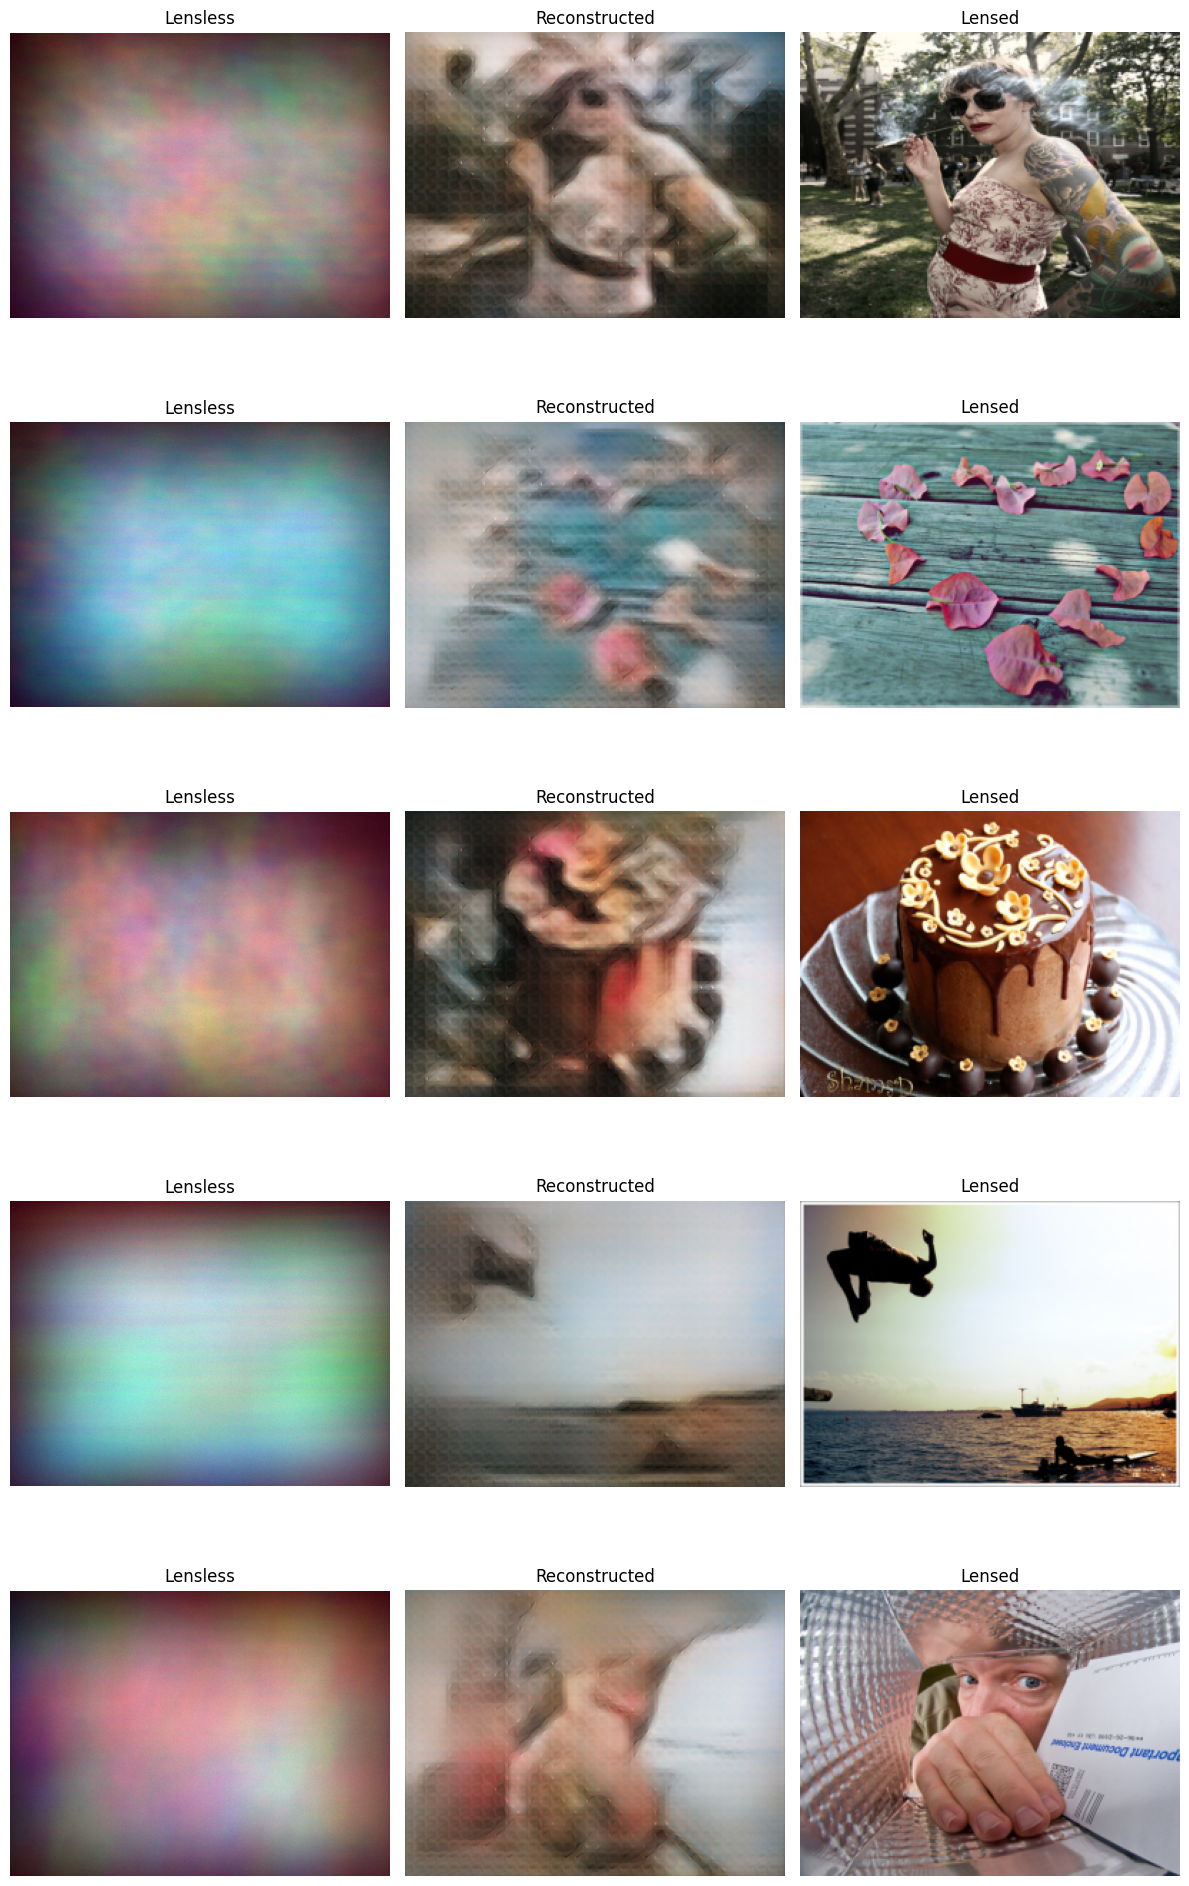

In [10]:
from src.lensless_helpers.preprocessor import get_dataset_object, get_roi

# --------------------
# You can adjust number of images to show

N_SHOW = 5

# --------------------

lensless_dir = DATA_DIR / "lensless"
lensed_dir = DATA_DIR / "lensed"
has_lensed = lensed_dir.is_dir() and any(lensed_dir.glob("*.png"))

pred_paths = sorted(PRED_DIR.glob("*.png"))[:N_SHOW]
n_cols = 3 if has_lensed else 2

fig, axes = plt.subplots(len(pred_paths), n_cols, figsize=(4 * n_cols, 4 * len(pred_paths)))
if len(pred_paths) == 1:
    axes = axes[None, :]

for row, pred_path in enumerate(pred_paths):
    image_id = pred_path.stem
    axes[row, 0].imshow(Image.open(lensless_dir / f"{image_id}.png"))
    axes[row, 0].set_title("Lensless")
    axes[row, 1].imshow(Image.open(pred_path))
    axes[row, 1].set_title("Reconstructed")
    if has_lensed:
        lensed, _, _ = get_dataset_object(
            Image.open(lensed_dir / f"{image_id}.png"),
            Image.open(lensless_dir / f"{image_id}.png"),
            None
        )
        lensed = get_roi(lensed.permute(2, 0, 1)).permute(1, 2, 0).numpy()
        axes[row, 2].imshow(lensed)
        axes[row, 2].set_title("Lensed")

    for c in range(n_cols):
        axes[row, c].axis("off")

plt.tight_layout()
plt.show()


### Metrics

Final metrics calculation

In [12]:
if has_lensed:
    res = subprocess.run(
        [sys.executable, "scripts/calculate_metrics.py", "--gt", lensed_dir, "--pred", PRED_DIR],
        capture_output=True, text=True,
    )
    print(res.stdout)
else:
    print("No 'lensed/' folder -> ground truth unavailable, metrics skipped")


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /Users/maksim/PycharmProjects/DL_HSE/hw5/lensless/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Metrics over 50 image(s):
    MSEMetric                                 : 0.025926
    LPIPSMetric                               : 0.578260
    PeakSignalNoiseRatioMetric                : 16.556079
    StructuralSimilarityIndexMeasureMetric    : 0.408291

